# Assignment 11
## Submitted by Chaitanya Jindal

In [28]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Loading the data

In [8]:
df = pd.read_csv("monthly_crop_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.head(), df.shape

(        Date  Production
 0 1962-01-01         589
 1 1962-02-01         561
 2 1962-03-01         640
 3 1962-04-01         656
 4 1962-05-01         727,
 (168, 2))

#### Visualising the data

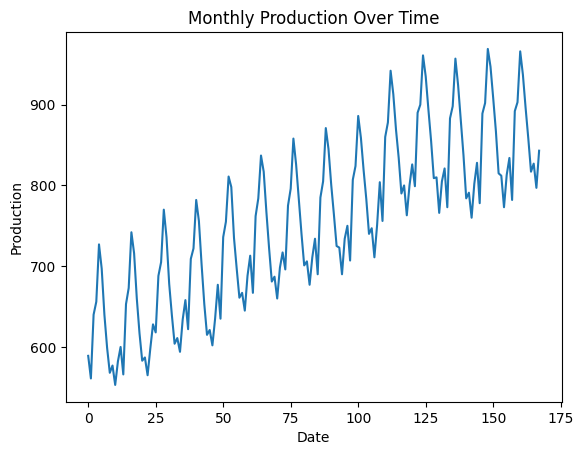

In [12]:
plt.plot(df.index, df["Production"])
plt.title("Monthly Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

In [23]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

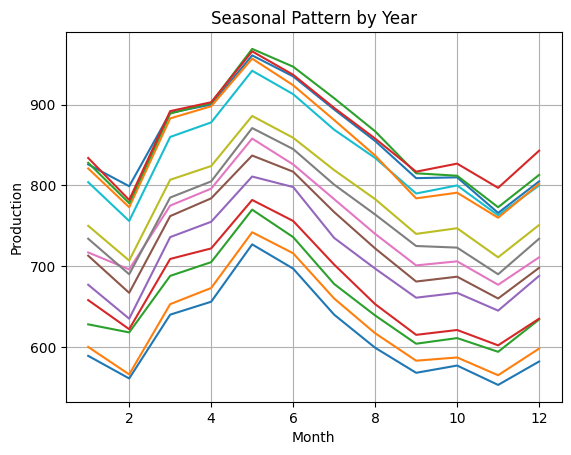

In [25]:
for year in range(1962, 1976):
    temp = df[df["Year"] == year]
    plt.plot(temp["Month"], temp["Production"], label=str(year))
plt.title("Seasonal Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Production")
plt.grid(True)
plt.show()

#### ADF Test

In [26]:
result = adfuller(df["Production"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -1.3038115874221263
p-value: 0.6274267086030331
Critical Values:
1% : -3.473542528196209
5% : -2.880497674144038
10% : -2.576878053634677


##### The data is non-stationary

In [30]:
df["Diff_1"] = df["Production"].diff()
first_difference = adfuller(df["Diff_1"].dropna())
print("ADF Statistic:", first_difference[0])
print("p-value:", first_difference[1])
print("Critical Values:")
for key, value in first_difference[4].items():
    print(key, ":", value)

ADF Statistic: -3.0549955586530637
p-value: 0.03006800400178615
Critical Values:
1% : -3.474120870218417
5% : -2.880749791423677
10% : -2.5770126333102494


#### Train-test split and model selection

Because this is a monthly series with visible trend and seasonality, I am using exponential smoothing.
The last 12 months are kept as a test set to compare candidate models.


In [31]:
train_data = df.iloc[:-12]
test_data = df.iloc[-12:]

model = ExponentialSmoothing(
    train_data['Production'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

In [39]:
test_predictions = model.forecast(12)
test_predictions

156    843.084408
157    799.632850
158    908.097364
159    927.398227
160    999.580172
161    968.684306
162    912.917919
163    865.763650
164    817.631608
165    822.864662
166    787.999478
167    831.861767
dtype: float64

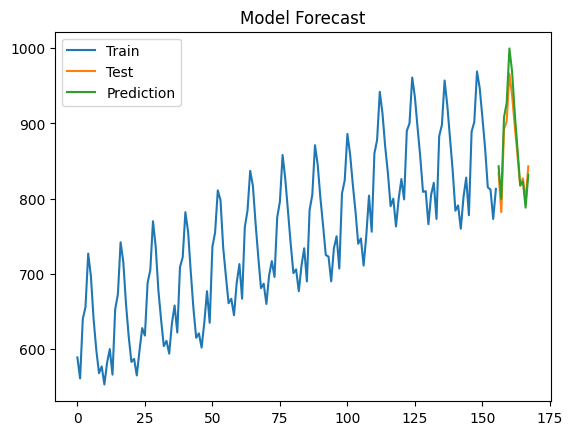

In [40]:
plt.plot(train_data['Production'], label='Train')
plt.plot(test_data['Production'], label='Test')
plt.plot(test_predictions, label='Prediction')
plt.legend()
plt.title("Model Forecast")
plt.show()

#### Model Evaluation

In [41]:
mae = mean_absolute_error(test_data['Production'], test_predictions)
rmse = np.sqrt(mean_squared_error(test_data['Production'], test_predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 15.17
Root Mean Squared Error (RMSE): 18.14


#### Future Forecasting (5 Years)

In [42]:
final_model = ExponentialSmoothing(
    df['Production'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

future_forecast = final_model.forecast(60)

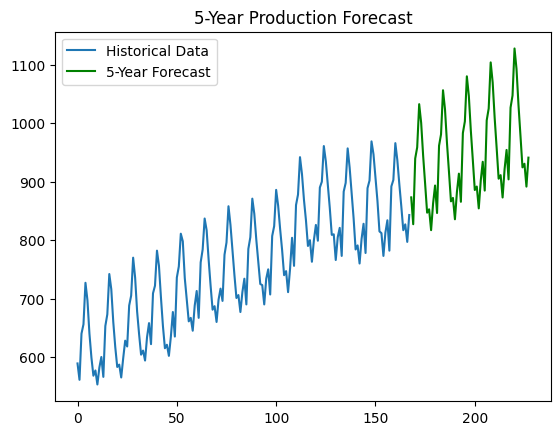

In [43]:
plt.plot(df['Production'], label='Historical Data')
plt.plot(future_forecast, label='5-Year Forecast', color='green')
plt.title("5-Year Production Forecast")
plt.legend()
plt.show()

In [44]:
print(future_forecast.head())

168     873.179982
169     827.225213
170     939.724297
171     958.844407
172    1032.686689
dtype: float64
